In [1]:
import numpy as np
import jax.random as jr
import jax
import jax.numpy as jnp
import timeit
import matplotlib.pyplot as plt
import torch

from generator import init_inputs, make_net, generate_samples
from fosters_method import mom4_jax
from src.evaluation.shuffle_prod import nth_moments
from src.evaluation.evaluation import fourth_moment_errors


def compute_time(noise_size, hidden_dim, num_layers, bm_dim, num_samples, use_gan=True, print_results=True):
    num_reps = 10
    key = jr.key(0)
    key_net, key_inputs, key_method = jr.split(key, 3)
    w, hh, triu_indices = init_inputs(key_inputs, num_samples, bm_dim)
    if use_gan:
        net = make_net(key_net, noise_size, hidden_dim, num_layers)
        fun = lambda hh_in: generate_samples(key_method, net, triu_indices, w, hh_in)
    else:
        keys_method = jr.split(key_method, num_samples)
        fun = lambda hh_in: mom4_jax(keys_method, triu_indices, w, hh_in, None)
    
    # without feeding hh
    fn_without = lambda : jax.block_until_ready(fun(None))
    fn_without()  # warmup
    time_without_hh = timeit.repeat(fn_without, number=num_reps, repeat=20)  # measure
    
    # with feeding hh
    fn_with = lambda : jax.block_until_ready(fun(hh))
    fn_with()  # warmup
    time_with_hh = timeit.repeat(fn_with, number=num_reps, repeat=20)  # measure
    
    # compute mean and stdev
    mean_without_hh = np.mean(time_without_hh)/num_reps
    stdev_without_hh = np.std(time_without_hh)/num_reps
    mean_with_hh = np.mean(time_with_hh)/num_reps
    stdev_with_hh = np.std(time_with_hh)/num_reps
    if print_results:
        print(f"Without feeding hh: {mean_without_hh:.4} ± {stdev_without_hh:.4} seconds")
        print(f"With feeding hh: {mean_with_hh:.4} ± {stdev_with_hh:.4} seconds")
    return mean_without_hh, mean_with_hh

In [2]:
gan_without_hh, gan_with_hh = compute_time(4, 16, 3, 4, 2 ** 20, use_gan=True)

Without feeding hh: 0.01147 ± 0.0003712 seconds
With feeding hh: 0.01121 ± 0.0002307 seconds


In [3]:
mom4_without_hh, mom4_with_hh = compute_time(4, 16, 3, 4, 2 ** 20, use_gan=False)

Without feeding hh: 0.003597 ± 0.0002047 seconds
With feeding hh: 0.003229 ± 0.0001111 seconds


Ratio for 1024 samples: without hh: 1.546, with hh: 1.06
Ratio for 2048 samples: without hh: 1.66, with hh: 1.986
Ratio for 4096 samples: without hh: 1.326, with hh: 1.301
Ratio for 8192 samples: without hh: 1.923, with hh: 1.523
Ratio for 16384 samples: without hh: 1.824, with hh: 1.559
Ratio for 32768 samples: without hh: 2.834, with hh: 2.461
Ratio for 65536 samples: without hh: 5.364, with hh: 4.474
Ratio for 131072 samples: without hh: 7.998, with hh: 9.073
Ratio for 262144 samples: without hh: 7.244, with hh: 5.666
Ratio for 524288 samples: without hh: 3.749, with hh: 3.687


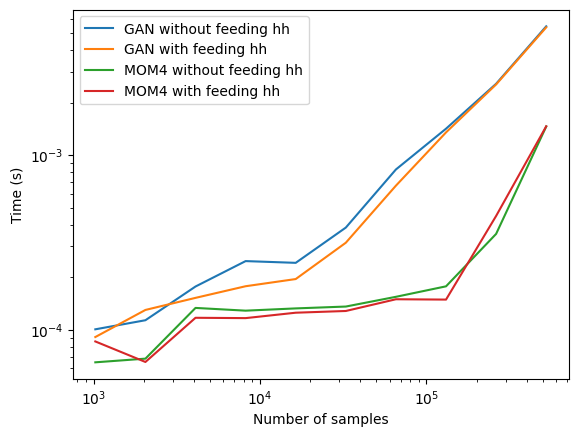

In [4]:
# Plot how the time of both methods changes with the number of samples

num_samples = 2 ** np.arange(10, 20)
times_gan_without_hh = np.zeros_like(num_samples, dtype=float)
times_gan_with_hh = np.zeros_like(num_samples, dtype=float)
times_mom4_without_hh = np.zeros_like(num_samples, dtype=float)
times_mom4_with_hh = np.zeros_like(num_samples, dtype=float)

for i, n in enumerate(num_samples):
    tg_without, tg_with = compute_time(4, 16, 3, 4, n, use_gan=True, print_results=False)
    times_gan_without_hh[i] = tg_without
    times_gan_with_hh[i] = tg_with
    tm_without, tm_with = compute_time(4, 16, 3, 4, n, use_gan=False, print_results=False)
    times_mom4_without_hh[i] = tm_without
    times_mom4_with_hh[i] = tm_with
    print(f"Ratio for {n} samples: without hh: {tg_without/tm_without:.4}, with hh: {tg_with/tm_with:.4}")

plt.figure()
plt.plot(num_samples, times_gan_without_hh, label="GAN without feeding hh")
plt.plot(num_samples, times_gan_with_hh, label="GAN with feeding hh")
plt.plot(num_samples, times_mom4_without_hh, label="MOM4 without feeding hh")
plt.plot(num_samples, times_mom4_with_hh, label="MOM4 with feeding hh")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of samples")
plt.ylabel("Time (s)")
plt.legend()

Ratio for bm_dim=2: without hh: 1.248, with hh: 1.806
Ratio for bm_dim=3: without hh: 1.308, with hh: 1.634
Ratio for bm_dim=4: without hh: 1.972, with hh: 1.602
Ratio for bm_dim=5: without hh: 2.226, with hh: 2.208
Ratio for bm_dim=6: without hh: 3.35, with hh: 2.778
Ratio for bm_dim=7: without hh: 4.364, with hh: 2.9
Ratio for bm_dim=8: without hh: 6.401, with hh: 4.991
Ratio for bm_dim=9: without hh: 6.494, with hh: 7.007
Ratio for bm_dim=10: without hh: 9.208, with hh: 7.64
Ratio for bm_dim=11: without hh: 9.724, with hh: 8.865


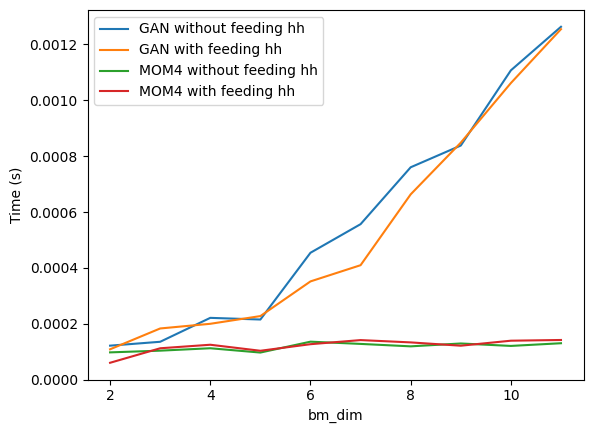

In [5]:
# now do the same thing but vary the bm_dim
bm_dims = np.arange(2, 12)
num_samples = 2**14
times_gan_without_hh = np.zeros_like(bm_dims, dtype=float)
times_gan_with_hh = np.zeros_like(bm_dims, dtype=float)
times_mom4_without_hh = np.zeros_like(bm_dims, dtype=float)
times_mom4_with_hh = np.zeros_like(bm_dims, dtype=float)

for i, bm_dim in enumerate(bm_dims):
    tg_without, tg_with = compute_time(4, 16, 3, bm_dim, num_samples, use_gan=True, print_results=False)
    times_gan_without_hh[i] = tg_without
    times_gan_with_hh[i] = tg_with
    tm_without, tm_with = compute_time(4, 16, 3, bm_dim, num_samples, use_gan=False, print_results=False)
    times_mom4_without_hh[i] = tm_without
    times_mom4_with_hh[i] = tm_with
    print(f"Ratio for bm_dim={bm_dim}: without hh: {tg_without/tm_without:.4}, with hh: {tg_with/tm_with:.4}")
    
plt.figure()
plt.plot(bm_dims, times_gan_without_hh, label="GAN without feeding hh")
plt.plot(bm_dims, times_gan_with_hh, label="GAN with feeding hh")
plt.plot(bm_dims, times_mom4_without_hh, label="MOM4 without feeding hh")
plt.plot(bm_dims, times_mom4_with_hh, label="MOM4 with feeding hh")
plt.xlabel("bm_dim")

plt.ylabel("Time (s)")
plt.legend()

plt.show()

In [6]:
# Just check that Foster's method works correctly
true_fourth_moments = nth_moments(4, 4)

In [7]:
w, hh, triu_indices = init_inputs(jr.key(4), 2**20, 4)
keys = jr.split(jr.key(5), 2**20)
_, _, _, foster_samples = mom4_jax(keys, triu_indices, w, hh, None)
print(jnp.mean(foster_samples, axis=0))
print(jnp.var(foster_samples, axis=0))
foster_samples_torch = torch.tensor(np.array(foster_samples))
errs_max, errs_rms, errs_mean = fourth_moment_errors(foster_samples_torch, true_fourth_moments, loss_type="all")
print(f"Max error: {errs_max:.4}, RMS error: {errs_rms:.4}, Mean error: {errs_mean:.4}")

[ 0.00027913 -0.00120639 -0.00026142  0.00050381 -0.00012058  0.00068808]
[0.24995004 0.25015914 0.24993506 0.25031936 0.2499471  0.24999154]
Max error: 0.003773, RMS error: 0.0006515, Mean error: 0.0004086
